In [36]:
ls

penguins_cytb.fasta  penguins_mass_cytb.csv  README.md
penguins_mass.csv    Python_script.ipynb     sequence_translate.py


In [37]:
cd /home/ddabiri/BCB546_Spring2024/assignments/BCB546_Spring2024/assignments/Python_Assignment


/home/ddabiri/BCB546_Spring2024/assignments/BCB546_Spring2024/assignments/Python_Assignment


In [38]:
ls

penguins_cytb.fasta  penguins_mass_cytb.csv  README.md
penguins_mass.csv    Python_script.ipynb     sequence_translate.py


In [39]:
pip install biopython


Note: you may need to restart the kernel to use updated packages.


In [41]:
import pandas as pd
from Bio import SeqIO
from Bio.Data import CodonTable
import pandas as pd


In [42]:
with open('penguins_cytb.fasta', 'r') as file:
    content = file.read()


In [43]:
def get_sequences_from_file(fasta_fn):
    """
    #Reads sequences from a FASTA file and returns them in a dictionary.

    Parameters:
    - fasta_fn (str): The filename of the FASTA file containing the sequences.

    Returns:
    - dict: A dictionary where keys are species names and values are corresponding sequences.
    """
    sequence_data_dict = {}
    for record in SeqIO.parse(fasta_fn, "fasta"):
        description = record.description.split()
        species_name = description[1] + " " + description[2]
        sequence_data_dict[species_name] = record.seq
    return sequence_data_dict


In [44]:
cytb_seqs = get_sequences_from_file("penguins_cytb.fasta") 

penguins_df = pd.read_csv("penguins_mass.csv") 
species_list = list(penguins_df.species)

In [45]:
sequences_dict = get_sequences_from_file("penguins_cytb.fasta")


In [46]:
from Bio.Data import CodonTable

def translate_function(string_nucleotides):
    """
    Translates a DNA sequence into an amino acid sequence.

    Parameters:
    - string_nucleotides (str): The DNA sequence to be translated.

    Returns:
    - str: The translated amino acid sequence.
    """
    mito_table = CodonTable.unambiguous_dna_by_name["Vertebrate Mitochondrial"]
    aa_seq_string = ""
    
    for i in range(0, len(string_nucleotides) - 2, 3):
        codon = string_nucleotides[i:i+3]
        if codon in mito_table.stop_codons:
            break
        aa = mito_table.forward_table[codon]
        aa_seq_string += aa
    
    return aa_seq_string


In [47]:
from Bio.Seq import Seq

def translate_function(string_nucleotides):
    # Create a BioPython Seq object from the input string
    seq = Seq(string_nucleotides)
    
    # Translate the sequence using the standard genetic code
    aa_seq = seq.translate()
    
    # Convert the translated sequence to a string
    aa_seq_string = str(aa_seq)
    
    return aa_seq_string


In [48]:
from Bio.SeqUtils.ProtParam import ProteinAnalysis

def compute_molecular_weight(aa_seq):
    # Create a ProteinAnalysis object from the amino acid sequence
    protein_analysis = ProteinAnalysis(aa_seq)
    
    # Calculate the molecular weight using the ProteinAnalysis object
    molecular_weight = protein_analysis.molecular_weight()
    return molecular_weight


In [49]:
def calculate_gc_content(dna_seq):
    # Count the occurrences of 'G' and 'C' in the DNA sequence
    gc_count = dna_seq.count('G') + dna_seq.count('C')
    
    # Calculate the total number of nucleotides in the sequence
    total_nucleotides = len(dna_seq)
    
    # Calculate the GC-content as the ratio of (G + C) / total nucleotides
    gc_content = gc_count / total_nucleotides
    
    return gc_content


In [50]:
import pandas as pd
from Bio.SeqUtils import GC
from Bio.SeqUtils.ProtParam import ProteinAnalysis

# Function to calculate molecular weight for each amino acid sequence
def calculate_molecular_weight(aa_seq):
    if aa_seq:
        return ProteinAnalysis(str(aa_seq)).molecular_weight()
    else:
        return float('NaN')  # Return NaN if the sequence is empty


In [51]:

def calculate_gc_content(dna_seq):
    if dna_seq:
        return GC(dna_seq)
    else:
        return float('NaN')  # Return NaN if the sequence is empty




In [52]:

penguins_df['molecular_weight'] = float('NaN')
penguins_df['GC_content'] = float('NaN')



In [53]:
penguins_df

,species,mass,molecular_weight,GC_content
0,Aptenodytes forsteri,28.00,NaN,NaN
1,Aptenodytes patagonicus,13.40,NaN,NaN
2,Eudyptes chrysocome,2.80,NaN,NaN
3,Eudyptes chrysolophus,4.50,NaN,NaN
4,Eudyptes sclateri,4.25,NaN,NaN
5,Eudyptula minor,1.60,NaN,NaN
6,Pygoscelis adeliae,4.60,NaN,NaN
7,Pygoscelis antarctica,4.10,NaN,NaN
8,Pygoscelis papua,6.10,NaN,NaN
9,Spheniscus demersus,3.20,NaN,NaN


In [54]:
for index, row in penguins_df.iterrows():
    species = row['species']
    if species in cytb_seqs:
        # Calculate molecular weight for the amino acid sequence
        aa_seq = cytb_seqs[species]
        molecular_weight = calculate_molecular_weight(aa_seq)
        penguins_df.at[index, 'molecular_weight'] = molecular_weight
        # Calculate GC content for the DNA sequence (assuming it exists in your DataFrame)
        dna_seq = cytb_seqs[species]
        gc_content = calculate_gc_content(dna_seq)
        penguins_df.at[index, 'GC_content'] = gc_content

        

In [55]:
penguins_df

,species,mass,molecular_weight,GC_content
0,Aptenodytes forsteri,28.00,100706.2480,48.381452
1,Aptenodytes patagonicus,13.40,100610.4134,49.693788
2,Eudyptes chrysocome,2.80,100947.4416,51.181102
3,Eudyptes chrysolophus,4.50,100909.1934,50.918635
4,Eudyptes sclateri,4.25,101003.5480,50.831146
5,Eudyptula minor,1.60,101031.1084,49.256343
6,Pygoscelis adeliae,4.60,100746.2704,49.081365
7,Pygoscelis antarctica,4.10,100311.3870,47.769029
8,Pygoscelis papua,6.10,100771.9904,47.156605
9,Spheniscus demersus,3.20,100874.6150,48.293963


In [56]:
cytb_seqs

{'Aptenodytes forsteri': Seq('ATGGCCCCAAATCTCCGAAAATCCCATCCCCTCCTAAAAATAATTAATAACTCC...TAA'),
 'Aptenodytes patagonicus': Seq('ATGGCCCCAAACCTCCGAAAATCCCATCCTCTCCTAAAAATAATTAATAACTCC...TAA'),
 'Eudyptes chrysocome': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'),
 'Eudyptes chrysolophus': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'),
 'Eudyptes sclateri': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCCCTCCTAAAAACAATCAATAACTCC...TAA'),
 'Eudyptula minor': Seq('ATGGCCCCCAACCTCCGAAAATCTCACCCCCTCCTAAAAATAATCAACAACTCT...TAA'),
 'Pygoscelis adeliae': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAATAATTAACAACTCC...TAA'),
 'Pygoscelis antarctica': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAATAATCAACAACTCC...TAG'),
 'Pygoscelis papua': Seq('ATGGCCCCCAACCTTCGAAAATCCCACCCTCTCCTAAAAATAATCAACAAATCC...TAG'),
 'Spheniscus demersus': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAACAATCAACAACTCC...TAA'),
 'Spheniscus humboldti': Seq('ATGGCCCCCAACCTCCGAAAATCCCACCCTCTCCTAAAAAC

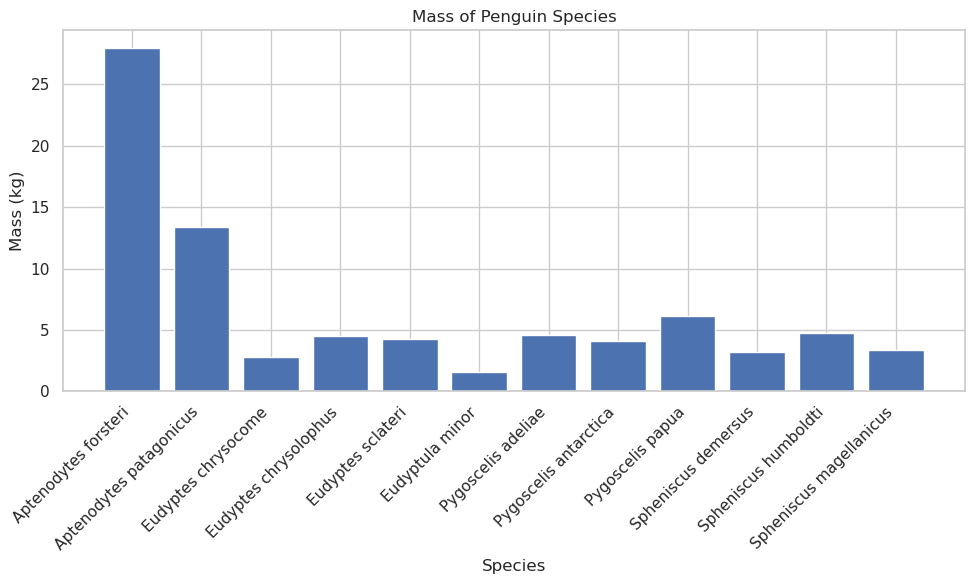

In [57]:
import matplotlib.pyplot as plt

# Plotting bar chart of mass with species names on the x-axis
plt.figure(figsize=(10, 6))
plt.bar(penguins_df['species'], penguins_df['mass'])
plt.xlabel('Species')
plt.ylabel('Mass (kg)')
plt.title('Mass of Penguin Species')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [58]:
smallest_penguin = penguins_df.loc[penguins_df['mass'].idxmin()]
smallest_species = smallest_penguin['species']
smallest_mass = smallest_penguin['mass']
print(f"The smallest penguin species is {smallest_species} with a mass of {smallest_mass} kg.")

The smallest penguin species is Eudyptula minor with a mass of 1.6 kg.


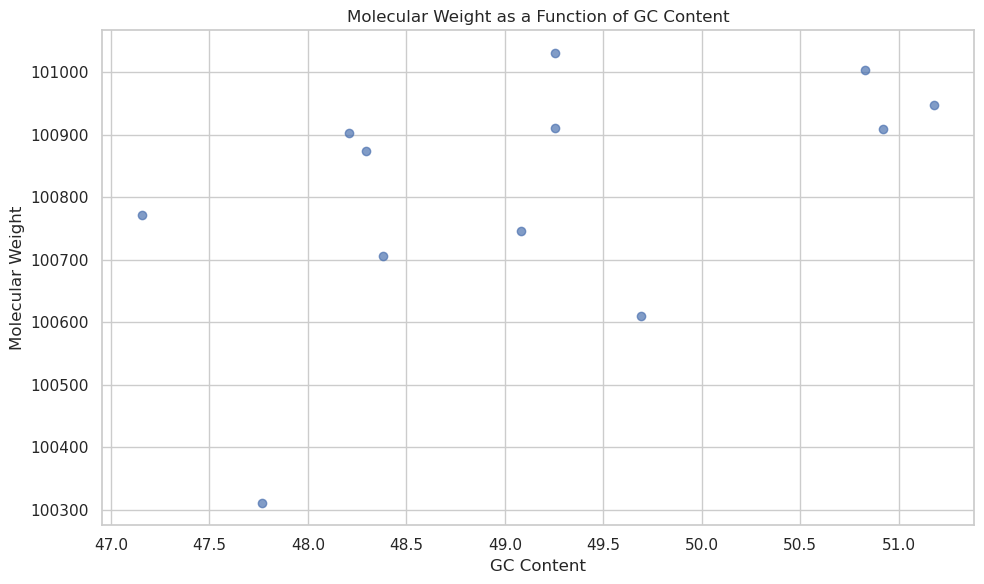

In [59]:
import matplotlib.pyplot as plt

# Plotting molecular weight as a function of GC-content
plt.figure(figsize=(10, 6))
plt.scatter(penguins_df['GC_content'], penguins_df['molecular_weight'], alpha=0.7)
plt.xlabel('GC Content')
plt.ylabel('Molecular Weight')
plt.title('Molecular Weight as a Function of GC Content')
plt.grid(True)
plt.tight_layout()
plt.show()


In [60]:
# Save the DataFrame to a CSV file
penguins_df.to_csv("penguins_mass_cytb.csv", index=False)


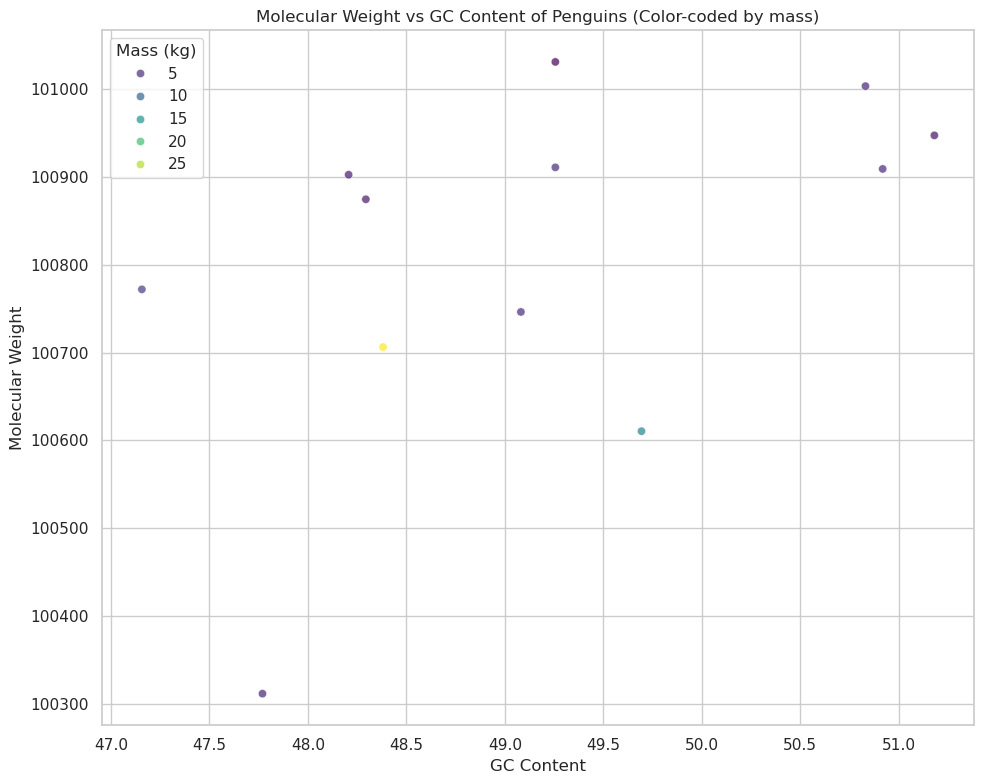

In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the seaborn style
sns.set(style="whitegrid")

# Create a scatter plot with molecular weight vs GC content, color-coded by mass
plt.figure(figsize=(10, 8))
sns.scatterplot(data=penguins_df, x='GC_content', y='molecular_weight', hue='mass', palette='viridis', alpha=0.7)
plt.xlabel('GC Content')
plt.ylabel('Molecular Weight')
plt.title('Molecular Weight vs GC Content of Penguins (Color-coded by mass)')
plt.legend(title='Mass (kg)')
plt.tight_layout()
plt.show()
